# Gene Program Overlap Analysis Across Runs

This notebook analyzes the overlap of gene programs (GPs) between different runs.
- Rows: GPs from one run
- Columns: GPs from another run
- Values: Number of overlapping genes between each GP pair

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from itertools import combinations
from scipy.optimize import linear_sum_assignment

matplotlib.rcParams['pdf.fonttype'] = 42

## Configuration

In [2]:
# Define runs to compare
RUNS = [0, 1, 2]
GPS = ['tgfb', 'tnfa']

# Base path template for GP cluster files
GP_CLUSTER_PATH = 'tripso_reproducibility/05_gpfinder/benchmark_retrain/{gp}/output_gpfinder_{run}/attention_simple/gpdb_clusters_corr.csv'

## Load Gene Programs

In [3]:
def load_gp_clusters(pathway, run_idx):
    """
    Load gene program clusters from a specific run.
    
    Parameters
    ----------
    pathway : str
        Either 'tgfb' or 'tnfa'
    run_idx : int
        Run index (e.g., 0, 1, 2)
        
    Returns
    -------
    dict
        Dictionary mapping GP name -> set of genes
    """
    path = GP_CLUSTER_PATH.format(gp=pathway, run=run_idx)
    
    if not os.path.exists(path):
        print(f"Warning: File not found: {path}")
        return {}
    
    df = pd.read_csv(path)
    
    # Convert each column to a set of genes (dropping NaN values)
    gp_dict = {}
    for col in df.columns:
        genes = set(df[col].dropna().tolist())
        gp_dict[col] = genes
    
    return gp_dict

# Load all GP clusters
gp_clusters = {}
for pathway in GPS:
    gp_clusters[pathway] = {}
    for run in RUNS:
        gps = load_gp_clusters(pathway, run)
        gp_clusters[pathway][run] = gps
        print(f"{pathway.upper()} - Run {run}: {len(gps)} GPs loaded")
        for gp_name, genes in gps.items():
            print(f"  {gp_name}: {len(genes)} genes")

TGFB - Run 0: 6 GPs loaded
  gp_0: 117 genes
  gp_1: 129 genes
  gp_2: 154 genes
  gp_3: 95 genes
  gp_4: 121 genes
  gp_5: 102 genes
TGFB - Run 1: 6 GPs loaded
  gp_0: 123 genes
  gp_1: 104 genes
  gp_2: 117 genes
  gp_3: 152 genes
  gp_4: 94 genes
  gp_5: 88 genes
TGFB - Run 2: 6 GPs loaded
  gp_0: 143 genes
  gp_1: 109 genes
  gp_2: 112 genes
  gp_3: 126 genes
  gp_4: 88 genes
  gp_5: 95 genes
TNFA - Run 0: 6 GPs loaded
  gp_0: 131 genes
  gp_1: 98 genes
  gp_2: 108 genes
  gp_3: 118 genes
  gp_4: 153 genes
  gp_5: 100 genes
TNFA - Run 1: 5 GPs loaded
  gp_0: 154 genes
  gp_1: 139 genes
  gp_2: 123 genes
  gp_3: 184 genes
  gp_4: 107 genes
TNFA - Run 2: 5 GPs loaded
  gp_0: 121 genes
  gp_1: 202 genes
  gp_2: 109 genes
  gp_3: 142 genes
  gp_4: 137 genes


## Calculate GP-to-GP Overlap

In [4]:
def calculate_gp_overlap_matrix(gp_dict_run1, gp_dict_run2, reorder=True):
    """
    Calculate overlap between all GPs from two different runs.
    
    Parameters
    ----------
    gp_dict_run1 : dict
        Dictionary of GP name -> gene set for run 1
    gp_dict_run2 : dict
        Dictionary of GP name -> gene set for run 2
    reorder : bool
        If True, reorder rows and columns to maximize diagonal values
        
    Returns
    -------
    pd.DataFrame
        Matrix where rows are GPs from run1, columns are GPs from run2,
        and values are the number of overlapping genes
    """
    gp_names_run1 = sorted(gp_dict_run1.keys())
    gp_names_run2 = sorted(gp_dict_run2.keys())
    
    # Create matrix (add 1 for unmatched row/column)
    matrix = np.zeros((len(gp_names_run1) + 1, len(gp_names_run2) + 1), dtype=int)
    
    # Get union of all genes in each run
    all_genes_run2 = set().union(*gp_dict_run2.values()) if gp_dict_run2 else set()
    all_genes_run1 = set().union(*gp_dict_run1.values()) if gp_dict_run1 else set()
    
    for i, gp1 in enumerate(gp_names_run1):
        for j, gp2 in enumerate(gp_names_run2):
            overlap = len(gp_dict_run1[gp1].intersection(gp_dict_run2[gp2]))
            matrix[i, j] = overlap
        
        # Calculate unmatched genes for this GP in run1
        # (genes that don't appear in ANY GP from run2)
        unmatched = len(gp_dict_run1[gp1] - all_genes_run2)
        matrix[i, -1] = unmatched
    
    # Calculate unmatched genes for each GP in run2
    for j, gp2 in enumerate(gp_names_run2):
        # (genes that don't appear in ANY GP from run1)
        unmatched = len(gp_dict_run2[gp2] - all_genes_run1)
        matrix[-1, j] = unmatched
    
    # Bottom-right corner: leave as 0 (no meaning for unmatched-unmatched)
    matrix[-1, -1] = 0
    
    # Reorder to maximize diagonal if requested (excluding unmatched row/col)
    if reorder and len(gp_names_run1) > 0 and len(gp_names_run2) > 0:
        # Use Hungarian algorithm to find optimal assignment on the main matrix
        main_matrix = matrix[:-1, :-1]
        row_ind, col_ind = linear_sum_assignment(-main_matrix)
        
        # Create full index arrays (including unmatched rows/cols if dimensions differ)
        n_rows, n_cols = main_matrix.shape
        
        # For rows: matched rows come first, then unmatched
        matched_rows = set(row_ind)
        unmatched_rows = [i for i in range(n_rows) if i not in matched_rows]
        full_row_ind = list(row_ind) + unmatched_rows
        
        # For columns: matched cols come first, then unmatched
        matched_cols = set(col_ind)
        unmatched_cols = [i for i in range(n_cols) if i not in matched_cols]
        full_col_ind = list(col_ind) + unmatched_cols
        
        # Reorder the main matrix
        matrix_reordered = np.zeros_like(matrix)
        matrix_reordered[:-1, :-1] = main_matrix[full_row_ind, :][:, full_col_ind]
        matrix_reordered[:-1, -1] = matrix[full_row_ind, -1]  # Reorder unmatched column
        matrix_reordered[-1, :-1] = matrix[-1, full_col_ind]  # Reorder unmatched row
        matrix_reordered[-1, -1] = 0
        
        matrix = matrix_reordered
        gp_names_run1 = [gp_names_run1[i] for i in full_row_ind]
        gp_names_run2 = [gp_names_run2[i] for i in full_col_ind]
    
    # Create labels with gene counts
    # row_labels = [f"{gp}\n(n={len(gp_dict_run1[gp])})" for gp in gp_names_run1]
    row_labels = [f"{gp.replace('_', ' ')}" for gp in gp_names_run1]
    row_labels.append("No\nmatch")
    
    # col_labels = [f"{gp}\n(n={len(gp_dict_run2[gp])})" for gp in gp_names_run2]
    col_labels = [f"{gp.replace('_', ' ')}" for gp in gp_names_run2]
    col_labels.append("No\nmatch")
    
    return pd.DataFrame(matrix, index=row_labels, columns=col_labels)

# Calculate overlap matrices for all pairwise comparisons
overlap_matrices = {}
for pathway in GPS:
    overlap_matrices[pathway] = {}
    for run_i, run_j in combinations(RUNS, 2):
        key = f"run{run_i}_vs_run{run_j}"
        overlap_matrices[pathway][key] = calculate_gp_overlap_matrix(
            gp_clusters[pathway][run_i],
            gp_clusters[pathway][run_j],
            reorder=True
        )
        print(f"\n{pathway.upper()} - {key}:")
        print(overlap_matrices[pathway][key])


TGFB - run0_vs_run1:
           gp 1  gp 0  gp 3  gp 4  gp 2  gp 5  No\nmatch
gp 0         96     1     2     0     1     0         17
gp 1          3   110     2     0     0     1         13
gp 2          0     0   142     0     1     1         10
gp 3          0     1     0    86     1     1          6
gp 4          0     1     1     0   108     0         11
gp 5          1     2     1     2     1    79         16
No\nmatch     4     8     4     6     5     6          0

TGFB - run0_vs_run2:
           gp 1  gp 2  gp 0  gp 4  gp 3  gp 5  No\nmatch
gp 0        100     1     2     0     2     1         11
gp 1          1    97     0     1     4     1         25
gp 2          1     0   136     0     1     3         13
gp 3          0     2     0    82     2     1          8
gp 4          0     0     1     1   109     1          9
gp 5          1     0     0     0     2    83         16
No\nmatch     6    12     4     4     6     5          0

TGFB - run1_vs_run2:
           gp 2  gp 1 

## Visualize GP Overlap Heatmaps

In [5]:
# # Create a single grid with all comparisons
# # Get all comparisons (sorted to ensure consistent order)
# all_comparisons = sorted(list(overlap_matrices[GPS[0]].keys()))
# n_comparisons = len(all_comparisons)

# # Create figure with subplots: 2 rows (TGFb, TNFa) x n_comparisons columns
# fig, axes = plt.subplots(2, n_comparisons, figsize=(8 * n_comparisons, 14))

# # Iterate through pathways and comparisons
# for row_idx, pathway in enumerate(GPS):
#     pathway_name = 'TGFb' if pathway == 'tgfb' else 'TNFa'
    
#     for col_idx, comparison in enumerate(all_comparisons):
#         matrix = overlap_matrices[pathway][comparison]
#         ax = axes[row_idx, col_idx]
        
#         # Plot heatmap
#         sns.heatmap(
#             matrix,
#             annot=True,
#             fmt='d',
#             cmap='YlOrRd',
#             cbar_kws={'label': 'Overlapping Genes'},
#             ax=ax,
#             linewidths=0.5,
#             linecolor='gray',
#             vmin=0
#         )
        
#         # Set title with pathway and comparison info
#         run_i = comparison.split("_vs_")[0].replace("run", "")
#         run_j = comparison.split("_vs_")[1].replace("run", "")
#         title = f'{pathway_name} - Run {run_i} vs Run {run_j}'
#         ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
        
#         # Set axis labels
#         ax.set_xlabel(f'Run {run_j} GPs', fontsize=10)
#         ax.set_ylabel(f'Run {run_i} GPs', fontsize=10)
        
#         # Rotate labels
#         ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
#         ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

# plt.tight_layout()
# plt.savefig('gp_overlap_comparison_grid.pdf', bbox_inches='tight', dpi=300)
# print("Saved: gp_overlap_comparison_grid.pdf")
# plt.show()

Saved: gp_overlap_comparison_single_row.pdf


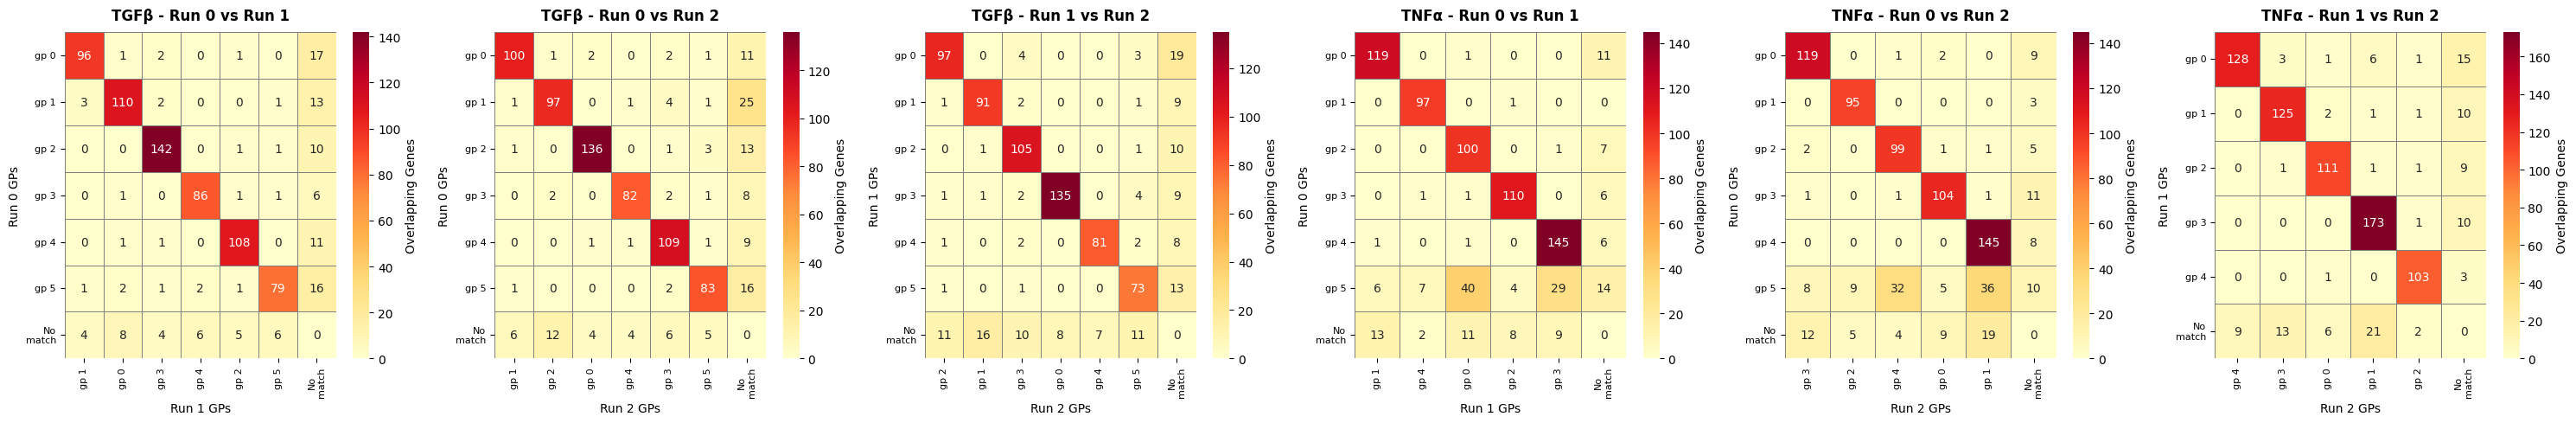

In [9]:
# Create a single row with all comparisons
# Get all comparisons (sorted to ensure consistent order)
all_comparisons = sorted(list(overlap_matrices[GPS[0]].keys()))
n_comparisons = len(all_comparisons)

# Create figure with subplots: 1 row x (2 * n_comparisons) columns
# Each comparison will have TGFb and TNFa side by side
fig, axes = plt.subplots(1, 2 * n_comparisons, figsize=(10 * n_comparisons, 5))

# Flatten axes array for easier indexing
axes = axes.flatten() if n_comparisons > 1 else [axes]

# Iterate through pathways first, then comparisons (all TGFβ, then all TNFα)
plot_idx = 0
for pathway in GPS:
    pathway_name = 'TGFβ' if pathway == 'tgfb' else 'TNFα'
    for col_idx, comparison in enumerate(all_comparisons):
        matrix = overlap_matrices[pathway][comparison]
        ax = axes[plot_idx]
        
        # Plot heatmap
        sns.heatmap(
            matrix,
            annot=True,
            fmt='d',
            cmap='YlOrRd',
            cbar_kws={'label': 'Overlapping Genes'},
            ax=ax,
            linewidths=0.5,
            linecolor='gray',
            vmin=0
        )
        
        # Set title with pathway and comparison info
        run_i = comparison.split("_vs_")[0].replace("run", "")
        run_j = comparison.split("_vs_")[1].replace("run", "")
        title = f'{pathway_name} - Run {run_i} vs Run {run_j}'
        ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
        
        # Set axis labels
        ax.set_xlabel(f'Run {run_j} GPs', fontsize=10)
        ax.set_ylabel(f'Run {run_i} GPs', fontsize=10)
        
        # Rotate labels and ensure proper formatting - use matrix index/columns to preserve newlines
        ax.set_xticklabels(matrix.columns, rotation=90, ha='center', fontsize=8)
        ax.set_yticklabels(matrix.index, rotation=0, ha='right', fontsize=8)
        
        plot_idx += 1

plt.tight_layout()
plt.savefig('gp_overlap_comparison_single_row.pdf', bbox_inches='tight', dpi=300)
print("Saved: gp_overlap_comparison_single_row.pdf")
plt.show()

## Summary Statistics

In [7]:
# Print summary statistics
print("=" * 80)
print("GP OVERLAP SUMMARY STATISTICS")
print("=" * 80)

for pathway in GPS:
    pathway_name = 'TGFb' if pathway == 'tgfb' else 'TNFa'
    print(f"\n{pathway_name}:")
    print("-" * 80)
    
    for comparison, matrix in overlap_matrices[pathway].items():
        print(f"\n  {comparison.replace('_', ' ').replace('run', 'Run ')}:")
        
        # Find max overlap for each row (best match for each GP in run1)
        for row_idx, row_label in enumerate(matrix.index):
            row_values = matrix.iloc[row_idx]
            max_val = row_values.max()
            max_col = row_values.idxmax()
            
            print(f"    {row_label} -> Best match: {max_col} (overlap: {max_val} genes)")
        
        # Overall statistics
        print(f"\n    Average overlap: {matrix.values.mean():.1f} genes")
        print(f"    Max overlap: {matrix.values.max()} genes")
        print(f"    Min overlap: {matrix.values.min()} genes")

GP OVERLAP SUMMARY STATISTICS

TGFb:
--------------------------------------------------------------------------------

  Run 0 vs Run 1:
    gp 0 -> Best match: gp 1 (overlap: 96 genes)
    gp 1 -> Best match: gp 0 (overlap: 110 genes)
    gp 2 -> Best match: gp 3 (overlap: 142 genes)
    gp 3 -> Best match: gp 4 (overlap: 86 genes)
    gp 4 -> Best match: gp 2 (overlap: 108 genes)
    gp 5 -> Best match: gp 5 (overlap: 79 genes)
    No
match -> Best match: gp 0 (overlap: 8 genes)

    Average overlap: 15.3 genes
    Max overlap: 142 genes
    Min overlap: 0 genes

  Run 0 vs Run 2:
    gp 0 -> Best match: gp 1 (overlap: 100 genes)
    gp 1 -> Best match: gp 2 (overlap: 97 genes)
    gp 2 -> Best match: gp 0 (overlap: 136 genes)
    gp 3 -> Best match: gp 4 (overlap: 82 genes)
    gp 4 -> Best match: gp 3 (overlap: 109 genes)
    gp 5 -> Best match: gp 5 (overlap: 83 genes)
    No
match -> Best match: gp 2 (overlap: 12 genes)

    Average overlap: 15.4 genes
    Max overlap: 136 genes


## Export Overlap Data

In [8]:
# # Save overlap matrices to CSV
# for pathway in GPS:
#     for comparison, matrix in overlap_matrices[pathway].items():
#         filename = f'{pathway}_gp_overlap_{comparison}.csv'
#         matrix.to_csv(filename)
#         print(f"Saved: {filename}")